In [1]:
import os
import re
import emcee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import astropy.units as u
from astropy.io import fits
from scipy.signal import convolve
from scipy.optimize import minimize
from linetools.spectra.lsf import LSF

In [2]:
target_directory = Path().resolve()
dla_directories = sorted([d for d in os.listdir(target_directory) if d.startswith("G130M") or d.startswith("E140M")])
print(dla_directories)
galaxy = target_directory.parts[target_directory.parts.index('float-for-morrow') + 1]

['E140M_1425_0.2x0.2_1200.000_9434']


In [3]:
def parse_directory(dirname):

    Target = target_directory.name

    parts = dirname.split("_")

    Grating = parts[0]
    Cenwave = int(parts[1])
    T_exp = str(parts[3])
    PID = int(parts[4])

    if Grating.startswith("G"):
        
        Instrument = "COS"
        LP = parts[2]

        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": LP, 
            "Aperture": None, 
            "T_exp": T_exp, 
            "PID": PID, 
        }
        
    else:
        
        Instrument = "STIS"
        Aperture = parts[2]
        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": None, 
            "Aperture": Aperture, 
            "T_exp": T_exp, 
            "PID": PID, 
        }

records = [parse_directory(d) for d in dla_directories]
df = pd.DataFrame.from_records(records)
display(df)

,Target,Instrument,Grating,Cenwave,LP,Aperture,T_exp,PID
0,SK 80,STIS,E140M,1425,None,0.2x0.2,1200.000,9434


In [4]:
def Ly_alpha_profile(wave, logN, z):

    N = 10.0 ** logN
    lambda0 = 1215.67 * (1.0 + z)
    return 4.26e-20 * N / (6.04e-10 + (wave - lambda0) ** 2)

In [5]:
def model_spectrum(wave, continuum, logN_mw, logN_sys, z_mw, z_sys, lsf):
    
    tau = Ly_alpha_profile(wave, logN_mw, z_mw) + Ly_alpha_profile(wave, logN_sys, z_sys)

    model = continuum * np.exp(-tau)
    model = convolve(model, lsf["kernel"], mode = "same")
    
    return model

In [6]:
def fit_hi_columns_mcmc(i, wave, flux, err, z_mw, z_sys, cont_windows, fit_windows):

    if galaxy == "LMC":
        prior_mean_mw = 20.7284
        prior_err_mw = 0.0585
    elif galaxy == "SMC":
        prior_mean_mw = 20.4983
        prior_err_mw = 0.0255

    Grating = df["Grating"].tolist()[i]
    if Grating.startswith("G"):
        lsf_obj = LSF(dict(name = df["Instrument"].tolist()[i], grating = df["Grating"].tolist()[i], life_position = str(df["LP"].tolist()[i].lstrip("LP")), cen_wave = str(df["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic') # Akima is troublesome for COS
    else:
        lsf_obj = LSF(dict(name = df["Instrument"].tolist()[i], grating = df["Grating"].tolist()[i], slit = str(df["Aperture"].tolist()[i]), cen_wave = str(df["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic')

    cont_mask = np.zeros_like(wave, dtype = bool)
    for bounds in cont_windows:
        cont_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    continuumfit = np.polyfit(wave[cont_mask], flux[cont_mask], 1) # Linear continuum
    cont = np.polyval(continuumfit, wave)

    flux_mask = np.zeros_like(wave, dtype = bool)
    for bounds in fit_windows:
        flux_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    masked_wave, masked_flux, masked_err, masked_cont = wave[flux_mask], flux[flux_mask], err[flux_mask], cont[flux_mask]

    def log_prob(x): # assuming Gaussian density, using https://emcee.readthedocs.io/en/stable/tutorials/quickstart/#quickstart

        logN_mw, logN_sys = x

        if not (18.0 <= logN_mw <= 22.5 and 18.0 <= logN_sys <= 22.0): # prior cutoff range for both systems
            return -np.inf

        log_prior_mw = - 0.5 * ((logN_mw - prior_mean_mw) / prior_err_mw) ** 2 - np.log(prior_err_mw * np.sqrt(2 * np.pi)) # prior from Welty et al. 2012, using the range of values as 3 sigma
        
        model = model_spectrum(masked_wave, masked_cont, logN_mw, logN_sys, z_mw, z_sys, lsf)
        res = (masked_flux - model) / masked_err
        log_likelihood = -0.5 * np.sum(res ** 2)

        return log_likelihood + log_prior_mw

    ndim, nwalkers = 2, 100
    p0 = np.empty((nwalkers, ndim))
    p0[:, 0] = np.random.normal(prior_mean_mw, prior_err_mw, nwalkers)
    p0[:, 1] = np.random.uniform(18.0, 22.5, nwalkers) # initial guess
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
    state = sampler.run_mcmc(p0, 100) # burn-in
    sampler.reset()
    sampler.run_mcmc(p0, 2000, progress = True);

    flat_samples = sampler.get_chain(flat = True)
    best_idx = np.argmax([log_prob(x) for x in flat_samples])
    best_mw, best_sys = flat_samples[best_idx]

    err_mw = 0.5 * (np.percentile(flat_samples[:, 0], 84) - np.percentile(flat_samples[:, 0], 16)) # estimate standard error by looking for the middle 68%
    err_sys = 0.5 * (np.percentile(flat_samples[:, 1], 84) - np.percentile(flat_samples[:, 1], 16))
    best_model = model_spectrum(wave, cont, best_mw, best_sys, z_mw, z_sys, lsf)

    return best_mw, err_mw, best_sys, err_sys, cont, best_model

In [7]:
def fit_hi_columns_mcmc(i, wave, flux, err, z_mw, z_sys, cont_windows, fit_windows):

    if galaxy == "LMC":
        n_mw_min = 2.6e20
        n_mw_max = 3.7e20
    elif galaxy == "SMC":
        n_mw_min = 3.3e20
        n_mw_max = 7.4e20

    prior_mean_mw = 0.5 * (n_mw_min + n_mw_max)
    prior_err_mw = (n_mw_max - n_mw_min) / 6.0 

    def log_prior_linear(N_mw):
        if N_mw <= 0:
            return -np.inf
        logp_mw = -0.5 * ((N_mw - prior_mean_mw) / prior_err_mw) ** 2 - np.log(prior_err_mw * np.sqrt(2 * np.pi))
        return logp_mw

    def log_prior_linear_sys(N_sys):
        return np.log(N_sys) + np.log(np.log(10.0))

    Grating = df["Grating"].tolist()[i]
    if Grating.startswith("G"):
        lsf_obj = LSF(dict(name = df["Instrument"].tolist()[i], grating = df["Grating"].tolist()[i], life_position = str(df["LP"].tolist()[i].lstrip("LP")), cen_wave = str(df["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic') # Akima is troublesome for COS
    else:
        lsf_obj = LSF(dict(name = df["Instrument"].tolist()[i], grating = df["Grating"].tolist()[i], slit = str(df["Aperture"].tolist()[i]), cen_wave = str(df["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic')

    cont_mask = np.zeros_like(wave, dtype = bool)
    for bounds in cont_windows:
        cont_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    continuumfit = np.polyfit(wave[cont_mask], flux[cont_mask], 1) # Linear continuum
    cont = np.polyval(continuumfit, wave)

    flux_mask = np.zeros_like(wave, dtype = bool)
    for bounds in fit_windows:
        flux_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    masked_wave, masked_flux, masked_err, masked_cont = wave[flux_mask], flux[flux_mask], err[flux_mask], cont[flux_mask]

    def log_prob(x):
        
        logN_mw, logN_sys = x
        if not (18.0 <= logN_mw <= 22.5 and 18.0 <= logN_sys <= 22.0): # prior cutoff range for both systems
            return -np.inf

        N_mw, N_sys = 10 ** logN_mw, 10 ** logN_sys
    
        log_prior_mw = log_prior_linear(N_mw)
        log_prior_sys = log_prior_linear_sys(N_sys)
    
        model = model_spectrum(masked_wave, masked_cont, logN_mw, logN_sys, z_mw, z_sys, lsf)
        res = (masked_flux - model) / masked_err
        log_likelihood = -0.5 * np.sum(res ** 2)
    
        return log_likelihood + log_prior_mw + log_prior_sys

    ndim, nwalkers = 2, 100
    p0 = np.empty((nwalkers, ndim))
    Nmw = np.random.normal(prior_mean_mw, prior_err_mw, nwalkers)

    bad = Nmw <= 0
    while np.any(bad):
        Nmw[bad] = np.random.normal(prior_mean_mw, prior_err_mw, bad.sum())
        bad = Nmw <= 0
    
    p0[:, 0] = np.log10(Nmw)
    # p0[:, 0] = np.log10(np.random.normal(prior_mean_mw, prior_err_mw, nwalkers))
    p0[:, 1] = np.random.uniform(18.0, 22.5, nwalkers) # initial guess
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
    state = sampler.run_mcmc(p0, 100) # burn-in
    sampler.reset()
    sampler.run_mcmc(p0, 2000, progress = True);

    flat_samples = sampler.get_chain(flat = True)
    best_idx = np.argmax([log_prob(x) for x in flat_samples])
    best_mw, best_sys = flat_samples[best_idx]

    err_mw = 0.5 * (np.percentile(flat_samples[:, 0], 84) - np.percentile(flat_samples[:, 0], 16)) # estimate standard error by looking for the middle 68%
    err_sys = 0.5 * (np.percentile(flat_samples[:, 1], 84) - np.percentile(flat_samples[:, 1], 16))
    best_model = model_spectrum(wave, cont, best_mw, best_sys, z_mw, z_sys, lsf)

    return best_mw, err_mw, best_sys, err_sys, cont, best_model

In [8]:
records = []

heliocentric_velocities_path = os.path.join(target_directory, "heliocentric_velocities.txt")

with open(heliocentric_velocities_path, "r") as file:
    lines = file.readlines()
    z_mw = float(lines[0].strip())
    z_sys = float(lines[1].strip())

cont_windows = [[1162, 1164], [1270, 1280]]
fit_windows = [[1170, 1172], [1180, 1182], [1196, 1198], [1202, 1205], [1222, 1224], [1230, 1232], [1252, 1253], [1255, 1257]]

for i in range(len(dla_directories)):

    directory = dla_directories[i]
    path = target_directory / directory

    for file in os.listdir(path):
        if file.endswith("_x1dsum.fits") or file.endswith("_x1d.fits"):

            src = path / file

            hdul = fits.open(src)
            wave = np.concatenate(hdul[1].data["WAVELENGTH"])
            flux = np.concatenate(hdul[1].data["FLUX"])
            err  = np.concatenate(hdul[1].data["ERROR"])

            sorted_indices = np.argsort(wave)
            wave = wave[sorted_indices]
            flux = flux[sorted_indices]
            err = err[sorted_indices]

            best_mw, err_mw, best_sys, err_sys, cont, best_model = fit_hi_columns_mcmc(i, wave, flux, err, z_mw, z_sys, cont_windows, fit_windows)

            records.append({
                "best_mw": best_mw,
                "err_mw": err_mw,
                "best_sys": best_sys,
                "err_sys": err_sys,
                "continuum": cont,
                "model": best_model
            })

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████| 2000/2000 [01:47<00:00, 18.57it/s]


In [9]:
df_records = pd.DataFrame(records)

In [10]:
def random_effects_mean(vals, sigmas):
    vals = np.asarray(vals, dtype = float)
    sigmas = np.asarray(sigmas, dtype = float)
    var = sigmas ** 2

    w  = 1.0 / var
    mu = (w * vals).sum() / w.sum()

    Q  = (w * (vals - mu) ** 2).sum()
    df = len(vals) - 1
    c  = w.sum() - (w ** 2).sum() / w.sum()
    T2 = max(0.0, (Q - df) / c) if c > 0 else 0.0

    w_re = 1.0 / (var + T2)
    mean = (w_re * vals).sum() / w_re.sum()
    std  = np.sqrt(1.0 / w_re.sum())
    return mean, std

mw_vals = df_records["best_mw"].values
mw_errs = df_records["err_mw"].values
sys_vals = df_records["best_sys"].values
sys_errs = df_records["err_sys"].values
best_mw, err_mw = random_effects_mean(mw_vals, mw_errs)
best_sys, err_sys = random_effects_mean(sys_vals, sys_errs)

In [11]:
print("log N(HI)_MW: ", f"{best_mw:.2f}", "+/-", f"{err_mw:.2f}")
print("log N(HI)_sys: ", f"{best_sys:.2f}", "+/-", f"{err_sys:.2f}")

log N(HI)_MW:  20.66 +/- 0.07
log N(HI)_sys:  20.98 +/- 0.03


In [12]:
output_path = os.path.join(target_directory, "NHI.txt")
with open(output_path, "w") as f:
    f.write(f"{best_sys:.8f}\n")   
    f.write(f"{err_sys:.8f}\n")   

In [13]:
directory = dla_directories[0]
path = target_directory / directory

for file in os.listdir(path):
    if file.endswith("_x1dsum.fits") or file.endswith("_x1d.fits"):

        src = path / file

        hdul = fits.open(src)
        example_wave = np.concatenate(hdul[1].data["WAVELENGTH"])
        example_flux = np.concatenate(hdul[1].data["FLUX"])
        example_err  = np.concatenate(hdul[1].data["ERROR"])

        sorted_indices = np.argsort(example_wave)
        example_wave = example_wave[sorted_indices]
        example_flux = example_flux[sorted_indices]
        example_err = example_err[sorted_indices]
        break

example_best_mw = records[0]["best_mw"]
example_err_mw = records[0]["err_mw"]
example_best_sys = records[0]["best_sys"]
example_err_sys = records[0]["err_sys"]
example_cont = records[0]["continuum"]
example_best_model = records[0]["model"]

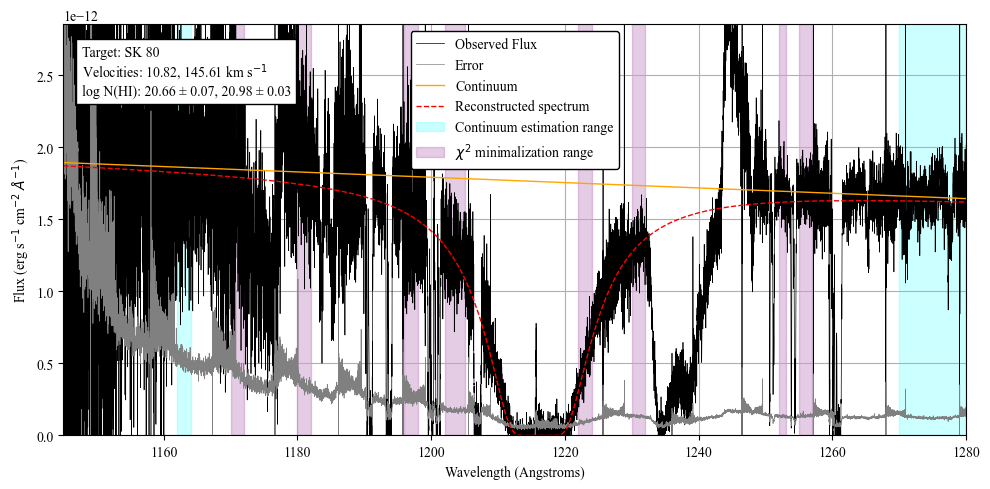

In [14]:
# plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.sans-serif"] = ["Gill Sans"]

plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize = (10, 5))
plt.plot(example_wave, example_flux, label = "Observed Flux", color = "black", lw = 0.5)
plt.plot(example_wave, example_err, label = "Error", color = "grey", lw = 0.5)
plt.plot(example_wave, example_cont, label = "Continuum", color = "orange", lw = 1)
plt.plot(example_wave, example_best_model, label = "Reconstructed spectrum", color = "red", lw = 1, linestyle = "--")

y_max = np.max(example_cont) * 1.5

for i in range(len(cont_windows)):
    bounds = cont_windows[i]
    if i == 0:
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, label = "Continuum estimation range", color = "cyan")
    else: 
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, color = "cyan")

for i in range(len(fit_windows)):
    bounds = fit_windows[i]
    if i == 0:
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, label = r"$\chi^2$ minimalization range", color = "purple")
    else: 
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, color = "purple")

row = df.iloc[0]

textstr = (
    f"Target: {row["Target"]}\n"
    f"Velocities: {(z_mw * 299792.458):.2f}, {(z_sys * 299792.458):.2f} km"r" s$^{-1}$""\n"
    f"log N(HI): {example_best_mw:.2f} ± {example_err_mw:.2f}, {example_best_sys:.2f} ± {example_err_sys:.2f}"
)
plt.gca().text(0.02, 0.95, textstr, transform = plt.gca().transAxes, verticalalignment = "top", bbox = dict(facecolor = "white", edgecolor = "black", alpha = 1.0))

plt.xlabel("Wavelength (Angstroms)")
plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
plt.xlim(1145, 1280)
plt.ylim(0, y_max)
plt.legend(framealpha = 1.0, facecolor = "white", edgecolor = "black")
plt.grid()
plt.tight_layout()
plt.savefig("NHI.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [15]:
# END